# La Neurona Artificial (y la Regresión Logística) en Keras

## 1. Configuración Google Drive

In [1]:
ruta = 'https://raw.githubusercontent.com/cagomezv/AP_USA/refs/heads/main/Semana_1/Data/dataset_Neu_Keras.csv'

## 2. Lectura y visualización del set de datos

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
import tensorflow as tf
np.random.seed(50)
tf.random.set_seed(25)

In [3]:
data = pd.read_csv(ruta)

In [4]:
data.head()

,x1,x2,y
0,1.0,7.0,1
1,4.0,0.5,0
2,6.0,3.0,1
3,1.0,4.0,0
4,3.0,4.5,1


In [5]:
data.shape

(14, 3)

In [6]:
X = data[['x1','x2']].to_numpy()
X.shape

(14, 2)

In [7]:
y = data[['y']].to_numpy()
y.shape
print(y)

[[1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]]


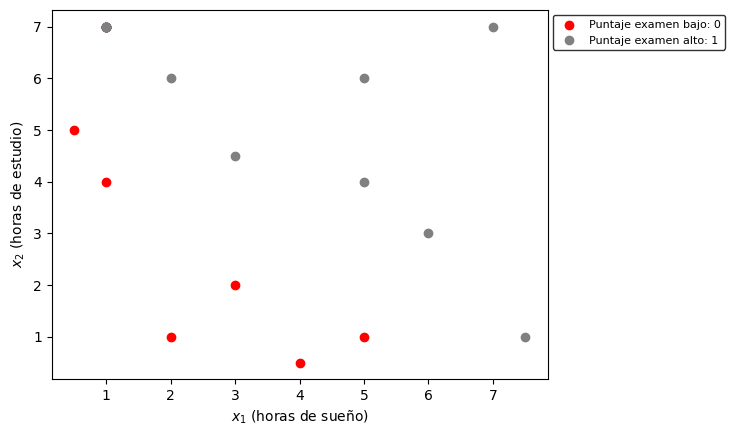

In [9]:
idx0 = np.where(y==0) # Puntaje examen bajo
idx1 = np.where(y==1) # Puntaje examen alto

plt.scatter(X[idx0,0],X[idx0,1],color='red',label='Puntaje examen bajo: 0')
plt.scatter(X[idx1,0],X[idx1,1],color='gray',label='Puntaje examen alto: 1')
plt.xlabel('$x_1$ (horas de sueño)')
plt.ylabel('$x_2$ (horas de estudio)')
plt.legend(bbox_to_anchor=(1.0,1.0),fontsize=8,edgecolor='black')
plt.show()

## 3. Crear la Neurona Artificial (modelo de Regresión Logística/Clasificación binaria) en Keras

In [14]:
# Contenedor vacío
modelo = Sequential()

In [16]:
# Parámetros de entrada del modelo
dim_entrada = X.shape[1]    # Cada ejemplo de entrenamiento tendrá 2 características (x1,x2)
dim_salida = 1              # El dato de salida será un escalar (probabilidad)

# Comenzar a llenar el modelo ('add')
# Entrada
modelo.add(Input(shape=(dim_entrada,)))
# Neurona/capa
modelo.add(Dense(dim_salida, activation='sigmoid'))
# ¡Y listo, ya tenemos la neurona!

In [17]:
# Información del modelo: w1x1 + w2x2 + b
modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Optimizador (Gradiente Descendente Estocástico) y pérdida

In [18]:
# Optimización: se usará gradiente descendente (SGD) con lr=0.2, función de error entropía
# cruzada (binary_crossentropy), métrica para el desempeño: accuracy (precisión)

optimizador = SGD(learning_rate=0.4)
modelo.compile(loss='binary_crossentropy', optimizer=optimizador, metrics=['accuracy'])

## 5. Entrenamiento y predicción

In [19]:
n_epochs = 100
s_minibatches = X.shape[0]  # Cada batch será del mismo tamaño del set de entrenamiento
historia = modelo.fit(X,y,epochs=n_epochs,batch_size=s_minibatches,verbose=1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.5714 - loss: 0.8231
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5714 - loss: 0.6814
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5714 - loss: 0.6220
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5714 - loss: 0.6068
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5714 - loss: 0.6253
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7857 - loss: 0.6193
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5714 - loss: 0.6791
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7857 - loss: 0.6183
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5714 - loss: 0.6869
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7857 - loss: 0.6024
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5714 - loss: 0.6624
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7857 - l

### 5.1 Comportamiento del error

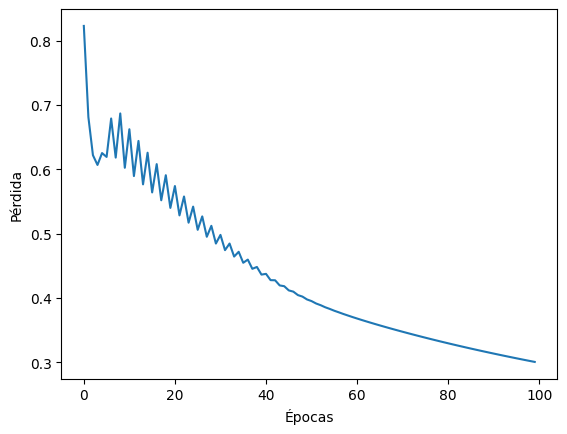

In [20]:
plt.plot(historia.history['loss'])
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.show()

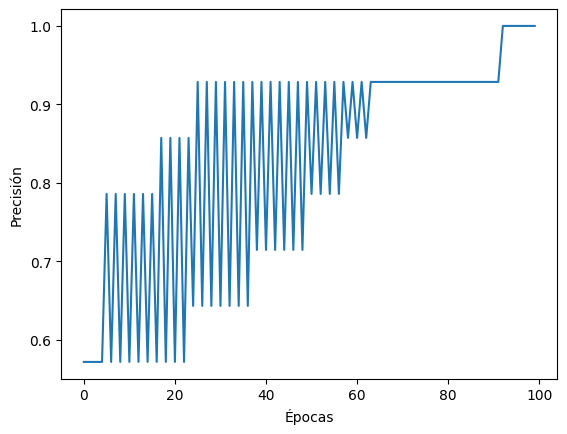

In [21]:
plt.plot(historia.history['accuracy'])
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.show()

### 5.2 Predicción

18750/18750 ━━━━━━━━━━━━━━━━━━━━ 21s 1ms/step


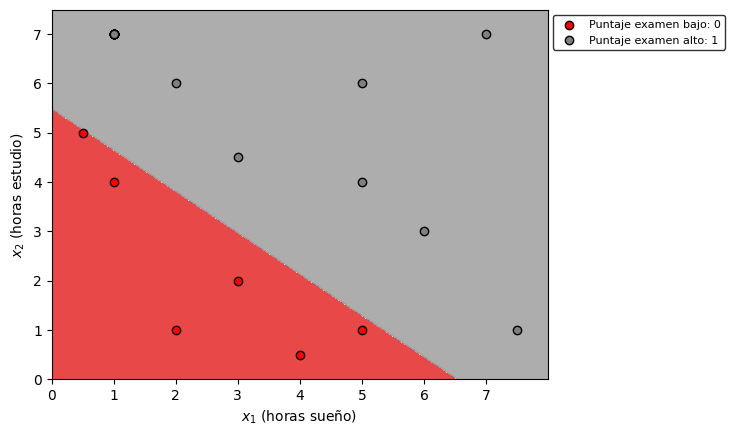

In [22]:
def dibujar_frontera(X,Y,modelo):
    # Valor mínimo y máximo y rellenado con ceros
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    h = 0.01

    # Grilla de puntos
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predecir categorías para cada punto en la grilla
    probabilidades = modelo.predict(np.c_[xx.ravel(), yy.ravel()])

    umbral = 0.5
    Z = np.where(probabilidades > umbral, 1, 0)
    #Z = modelo.predict_classes(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    fig = plt.figure()
    plt.contourf(xx, yy, Z, cmap=plt.cm.Set1, alpha=0.8)

    idx0 = np.where(Y==0)
    idx1 = np.where(Y==1)
    plt.scatter(X[idx0,0],X[idx0,1],color='red', edgecolor='k', label='Puntaje examen bajo: 0')
    plt.scatter(X[idx1,0],X[idx1,1],color='gray',edgecolor='k', label='Puntaje examen alto: 1')
    plt.legend(bbox_to_anchor=(1.0,1.0),fontsize=8,edgecolor='black')

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

    plt.xlabel('$x_1$ (horas sueño)')
    plt.ylabel('$x_2$ (horas estudio)')

dibujar_frontera(X,y,modelo)